# HealthConnect Clinic - Week 5 Analysis
### Data Analytics Track
**Intern:** Adeleke Jubril Adedeji

**Program:** AnalystLab Africa Experience Lab

---

## Week 4 Recap

**Problem:** HealthConnect Clinic wants to reduce missed appointments and improve patient support, using data to understand attendance patterns.

**Week 4 approach:** Reviewed the appointment dataset and data dictionary, ran an initial data quality assessment, explored variables against appointment outcomes, and proposed 5 business questions with 5 corresponding KPIs (booking lead time, previous no-show history, reminder status, age group, and appointment type).

**Relevant resources:** `HealthConnect_Appointment_Data.csv`, `HealthConnect_Data_Dictionary`.

**Key assumptions/limitations carried from Week 4:** Missing values in `reminder_channel`, `distance_to_clinic_km`, and `waiting_time_minutes` are limited and structural (not data errors) - the dictionary confirms these as expected gaps. The dataset is fictional and anonymised.

**Proposed Week 5 focus:** Calculate and interpret the 5 proposed KPIs, deepen the exploratory analysis on the strongest predictors identified in Week 4, and produce an initial dashboard alongside business insights.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


In [3]:
df = pd.read_csv(r"C:\Users\HP Dragon Fly\Downloads\HealthConnect_Appointment_Data.csv")
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## Part 1: Data Preparation

Before deepening the analysis, the dataset is re-checked to confirm it is still in the same condition as at the end of Week 4. The original file is not modified all checks below are read-only.

In [11]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFull duplicate rows:", df.duplicated().sum())
print("Duplicate appointment IDs:", df['appointment_id'].duplicated().sum())

Shape: (5000, 18)

Data types:
 appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

Missing values:
 appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_app

**Observation:** The dataset is unchanged from Week 4 5,000 rows, no duplicate rows or appointment IDs. The three columns with missing values (`reminder_channel`, `distance_to_clinic_km`, `waiting_time_minutes`) match the counts identified previously.

In [12]:
# Check that reminder_channel is blank exactly where reminder_sent = 'No' (structural, not an error)
mismatch = ((df['reminder_sent'] == 'No') != (df['reminder_channel'].isnull())).sum()
print("Rows where reminder_channel missingness does NOT match reminder_sent='No':", mismatch)

# Check categorical values for inconsistent labels/typos
cat_cols = ['gender','age_group','appointment_type','appointment_day','appointment_time',
            'reminder_sent','reminder_channel','appointment_outcome']
for c in cat_cols:
    print(f"{c}: {sorted(df[c].dropna().unique().tolist())}")

Rows where reminder_channel missingness does NOT match reminder_sent='No': 0
gender: ['Female', 'Male', 'Prefer not to say']
age_group: ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
appointment_type: ['Diagnostic Test', 'Follow-up', 'General Consultation', 'Specialist Consultation']
appointment_day: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
appointment_time: ['Afternoon', 'Evening', 'Morning']
reminder_sent: ['No', 'Yes']
reminder_channel: ['Email', 'SMS', 'WhatsApp']
appointment_outcome: ['Attended', 'Cancelled', 'No-Show']


**Data quality summary:**
- `reminder_channel` is blank in exactly the rows where no reminder was sent this confirms it is a structural gap, not missing data.
- `distance_to_clinic_km` (90 missing) and `waiting_time_minutes` (60 missing) remain limited and were already flagged in the data dictionary.
- No inconsistent category labels, casing issues, or unexpected values were found in any categorical column.
- No duplicate records exist.

The dataset is confirmed clean and ready for deeper analysis without further cleaning steps.

## Part 2: Exploratory Data Analysis

This section investigates appointment attendance and no-show patterns in more depth than Week 4, focusing on the relationships between outcomes and: booking behaviour, patient history, reminders, demographics, and clinic logistics.

No-show rates below are calculated as `No-Show / (Attended + No-Show)`, excluding Cancelled appointments, since a cancellation is a distinct outcome from a missed appointment.

Overall no-show rate (excluding cancellations): 51.2%


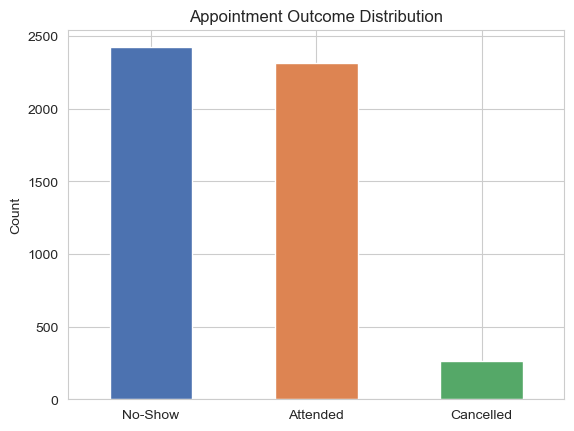

In [14]:
df_ns = df[df['appointment_outcome'].isin(['Attended','No-Show'])].copy()
df_ns['is_no_show'] = (df_ns['appointment_outcome'] == 'No-Show').astype(int)

overall_rate = df_ns['is_no_show'].mean() * 100
print(f"Overall no-show rate (excluding cancellations): {overall_rate:.1f}%")

df['appointment_outcome'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'],title='Appointment Outcome Distribution')

plt.ylabel('Count')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

### 2.1 Booking Lead Time

lead_bucket
0-7 days      29.5
8-14 days     35.2
15-30 days    45.5
31-60 days    63.9
Name: is_no_show, dtype: float64


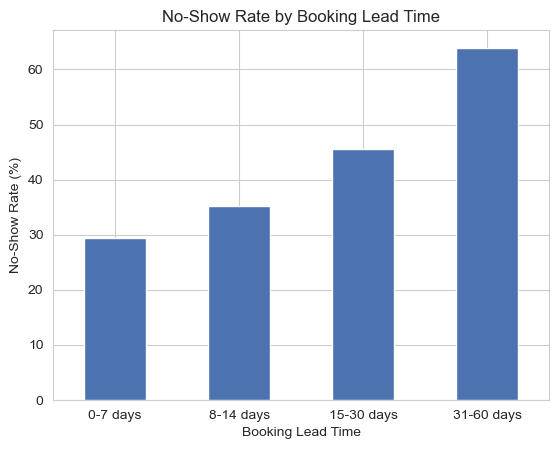

In [15]:
df_ns['lead_bucket'] = pd.cut(df_ns['booking_lead_days'], bins=[-1,7,14,30,60],
                              labels=['0-7 days','8-14 days','15-30 days','31-60 days'])
lead_rate = df_ns.groupby('lead_bucket', observed=True)['is_no_show'].mean() * 100
print(lead_rate.round(1))

lead_rate.plot(kind='bar', color='#4C72B0', title='No-Show Rate by Booking Lead Time')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Booking Lead Time')
plt.xticks(rotation=0)
plt.show()

**Observation:** No-show rate more than doubles as booking lead time increases from 29.5% for appointments booked within a week to 63.9% for those booked 31-60 days out. This remains the strongest single predictor of attendance, confirming Week 4's finding.

### 2.2 Previous No-Show History

prev_ns_bucket
0     46.3
1     55.9
2     62.1
3+    70.3
Name: is_no_show, dtype: float64


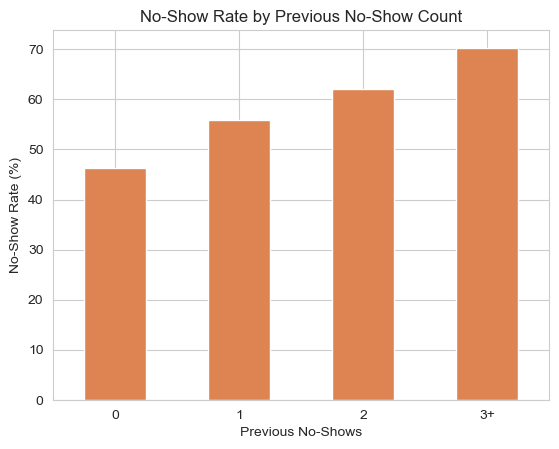

In [16]:
df_ns['prev_ns_bucket'] = pd.cut(df_ns['previous_no_shows'], bins=[-1,0,1,2,10], labels=['0','1','2','3+'])
prevns_rate = df_ns.groupby('prev_ns_bucket', observed=True)['is_no_show'].mean() * 100
print(prevns_rate.round(1))

prevns_rate.plot(kind='bar', color='#DD8452', title='No-Show Rate by Previous No-Show Count')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Previous No-Shows')
plt.xticks(rotation=0)
plt.show()

**Observation:** Patients with no prior no-shows still miss appointments at a notable 46.3% rate, but this climbs steadily to 70.3% for patients with 3 or more previous no-shows. Past behaviour is a strong indicator of future attendance risk.

### 2.3 Reminder Status

reminder_sent
No     54.6
Yes    49.9
Name: is_no_show, dtype: float64


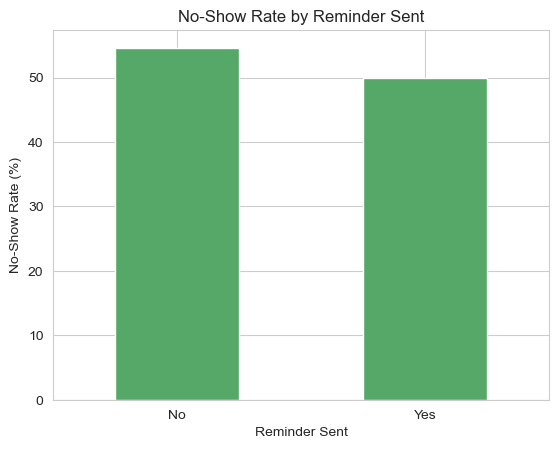

In [17]:
reminder_rate = df_ns.groupby('reminder_sent')['is_no_show'].mean() * 100
print(reminder_rate.round(1))

reminder_rate.plot(kind='bar', color='#55A868', title='No-Show Rate by Reminder Sent')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Reminder Sent')
plt.xticks(rotation=0)
plt.show()

**Observation:** Sending a reminder reduces the no-show rate by about 4.7 percentage points (54.6% -> 49.9%) a real but modest effect on its own. Section 2.7 below explores whether this effect is stronger for specific patient groups.

### 2.4 Age Group

age_group
18-24    52.4
25-34    52.9
35-44    51.4
45-54    51.1
55-64    53.0
65+      48.1
Name: is_no_show, dtype: float64


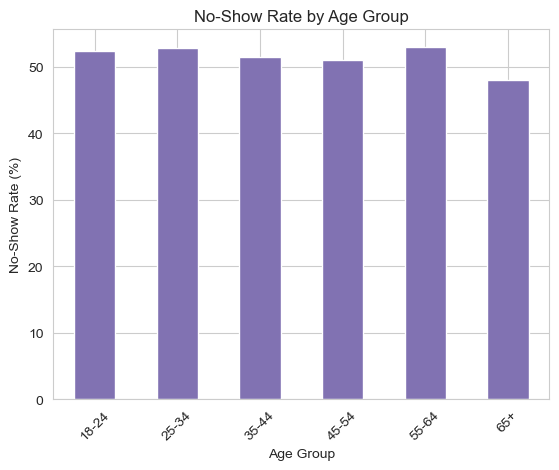

In [18]:
age_rate = df_ns.groupby('age_group', observed=True)['is_no_show'].mean().sort_index() * 100
print(age_rate.round(1))

age_rate.plot(kind='bar', color='#8172B2', title='No-Show Rate by Age Group')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

**Observation:** Age group shows little variation across most groups (51-53%), with the 65+ group modestly lower at 48.1%. Age alone is not a strong predictor of no-shows.

### 2.5 Appointment Type

appointment_type
Follow-up                  54.2
Diagnostic Test            52.0
Specialist Consultation    50.5
General Consultation       49.1
Name: is_no_show, dtype: float64


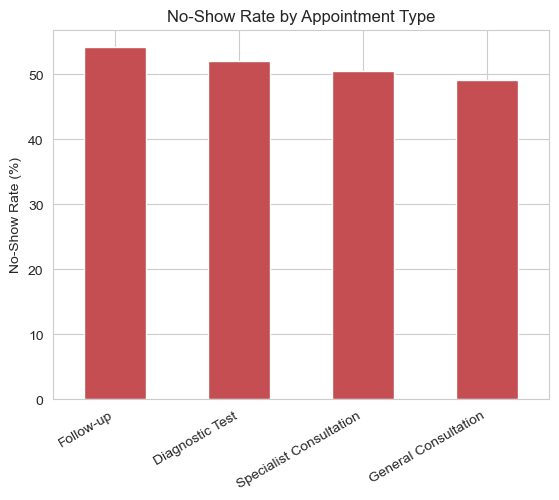

In [19]:
type_rate = df_ns.groupby('appointment_type')['is_no_show'].mean().sort_values(ascending=False) * 100
print(type_rate.round(1))

type_rate.plot(kind='bar', color='#C44E52', title='No-Show Rate by Appointment Type')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.show()

**Observation:** Follow-up appointments have the highest no-show rate (54.2%), while General Consultations have the lowest (49.1%). The spread is mild (~5 points) but consistent with Week 4's initial finding.

### 2.6 Distance to Clinic

dist_bucket
0-5km      48.7
5-10km     49.3
10-20km    52.3
20-50km    60.5
Name: is_no_show, dtype: float64


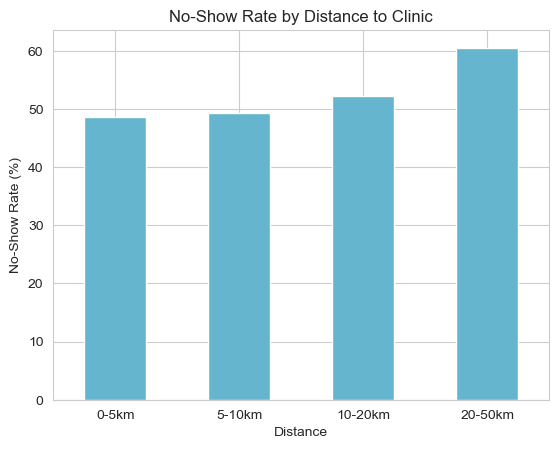

In [20]:
df_ns['dist_bucket'] = pd.cut(df_ns['distance_to_clinic_km'], bins=[0,5,10,20,50],
                              labels=['0-5km','5-10km','10-20km','20-50km'])
dist_rate = df_ns.groupby('dist_bucket', observed=True)['is_no_show'].mean() * 100
print(dist_rate.round(1))

dist_rate.plot(kind='bar', color='#64B5CD', title='No-Show Rate by Distance to Clinic')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Distance')
plt.xticks(rotation=0)
plt.show()

**Observation:** At this finer level of detail, distance does show a real effect at the tail end patients living 20-50km away have a notably higher no-show rate (60.5%) than those closer (48.7-49.3%). Week 4 described distance as negligible overall; this refines that finding rather than reversing it, since only a minority of patients fall in the farthest bracket.

### 2.7 Interaction: Booking Lead Time x Previous No-Shows

prev_ns_bucket     0     1     2    3+
lead_bucket                           
0-7 days        22.8  35.6  52.5  23.1
8-14 days       33.1  33.8  48.2  60.0
15-30 days      41.1  48.4  54.5  80.8
31-60 days      59.1  69.0  74.3  81.0


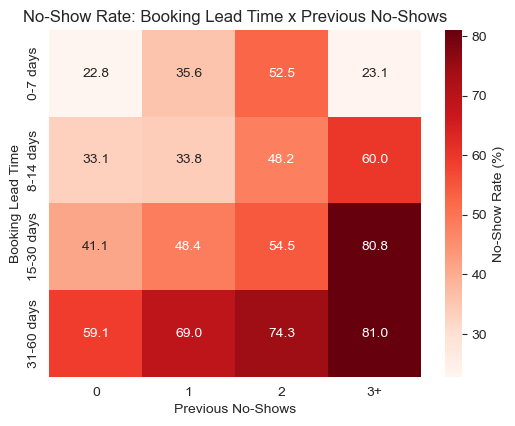

In [21]:
pivot = df_ns.pivot_table(index='lead_bucket', columns='prev_ns_bucket', values='is_no_show',
                          aggfunc='mean', observed=True) * 100
print(pivot.round(1))

plt.figure(figsize=(6,4.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label':'No-Show Rate (%)'})
plt.title('No-Show Rate: Booking Lead Time x Previous No-Shows')
plt.xlabel('Previous No-Shows')
plt.ylabel('Booking Lead Time')
plt.show()

**Observation:** The two strongest individual predictors compound when combined. A patient booking 31-60 days out with 3+ prior no-shows reaches an 81% no-show rate, compared to roughly 23-36% for patients booking within a week with 0-1 prior no-shows. This interaction is a stronger signal than either factor alone and is a strong candidate for prioritising outreach.

### 2.8 Does the Reminder Effect Vary by Risk Group?

reminder_sent     No   Yes
prev_ns_bucket            
0               49.0  45.3
1               58.7  54.8
2               70.7  58.7
3+              76.0  68.2


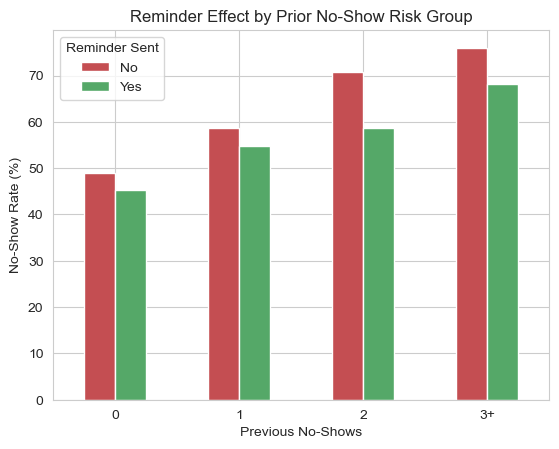

In [22]:
rem_risk = df_ns.pivot_table(index='prev_ns_bucket', columns='reminder_sent', values='is_no_show',
                             aggfunc='mean', observed=True) * 100
print(rem_risk.round(1))

rem_risk.plot(kind='bar', color=['#C44E52','#55A868'])
plt.title('Reminder Effect by Prior No-Show Risk Group')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Previous No-Shows')
plt.legend(title='Reminder Sent')
plt.xticks(rotation=0)
plt.show()

**Observation:** Reminders are more effective for higher-risk patients. For patients with 0 prior no-shows, a reminder reduces the no-show rate by only ~3.7 points, but for patients with 2 prior no-shows, the reduction is ~12 points. This suggests reminder outreach delivers more value when targeted at patients with a history of missed appointments, rather than sent uniformly to everyone.

## Part 3: KPI Development

Building on the 5 KPIs proposed in Week 4, each is now defined, calculated, and interpreted against its corresponding business question.

### KPI 1 - No-Show Rate by Booking Lead Time
**Definition:** The percentage of appointments resulting in a no-show, grouped by how many days in advance the appointment was booked.
**Why it matters:** Booking lead time is easy for the clinic to observe at the point of scheduling, making it a practical early signal of attendance risk.
**Business question:** Does how far in advance a patient books relate to whether they show up?
**Result:** 29.5% (0-7 days) -> 35.2% (8-14 days) -> 45.5% (15-30 days) -> 63.9% (31-60 days).
**Interpretation:** Longer lead times are strongly associated with higher no-show risk. The clinic could use lead time as a simple, real-time flag to trigger extra follow-up for appointments booked far in advance.

### KPI 2 - No-Show Rate by Previous No-Show History
**Definition:** The percentage of appointments resulting in a no-show, grouped by the patient's count of previous no-shows.
**Why it matters:** Past behaviour is often the most reliable predictor of future behaviour, and this data is already captured per patient.
**Business question:** Do patients with a history of missed appointments continue to miss appointments?
**Result:** 46.3% (0 prior) -> 55.9% (1 prior) -> 62.1% (2 prior) -> 70.3% (3+ prior).
**Interpretation:** Risk increases consistently with prior no-show count, confirming this as a reliable basis for a patient-level risk score.

### KPI 3 - No-Show Rate by Reminder Status
**Definition:** The percentage of appointments resulting in a no-show, split by whether a reminder was sent.
**Why it matters:** Reminders are a low-cost, actionable intervention the clinic can control directly.
**Business question:** Do reminders reduce missed appointments?
**Result:** 54.6% (no reminder) vs 49.9% (reminder sent) a 4.7-point reduction.
**Interpretation:** Reminders help, but the effect is modest on its own. Section 2.8 shows this effect is considerably stronger when reminders are targeted at higher-risk patients, which is a more actionable framing of this KPI.

### KPI 4 - No-Show Rate by Age Group
**Definition:** The percentage of appointments resulting in a no-show, grouped by patient age band.
**Why it matters:** Age is often assumed to relate to healthcare engagement, so it is worth testing directly.
**Business question:** Are certain age groups more likely to miss appointments?
**Result:** Ranges narrowly from 48.1% (65+) to 53.0% (55-64), with most groups close to the 51.2% overall average.
**Interpretation:** Age group is not a meaningful predictor on its own. Resources aimed at reducing no-shows are unlikely to be well-targeted by age alone.

### KPI 5 - No-Show Rate by Appointment Type
**Definition:** The percentage of appointments resulting in a no-show, grouped by the type of appointment booked.
**Why it matters:** Appointment type reflects the purpose of the visit and may relate to perceived urgency.
**Business question:** Are some types of appointments missed more often than others?
**Result:** Follow-up highest at 54.2%, General Consultation lowest at 49.1%.
**Interpretation:** The difference is real but mild (~5 points). Follow-up appointments may benefit from slightly more proactive reminder attention, since patients may perceive them as less urgent than a new consultation.

## Part 4: Dashboard / Analytical Visualisation

The chart below consolidates the five KPI results into a single view for quick reference.

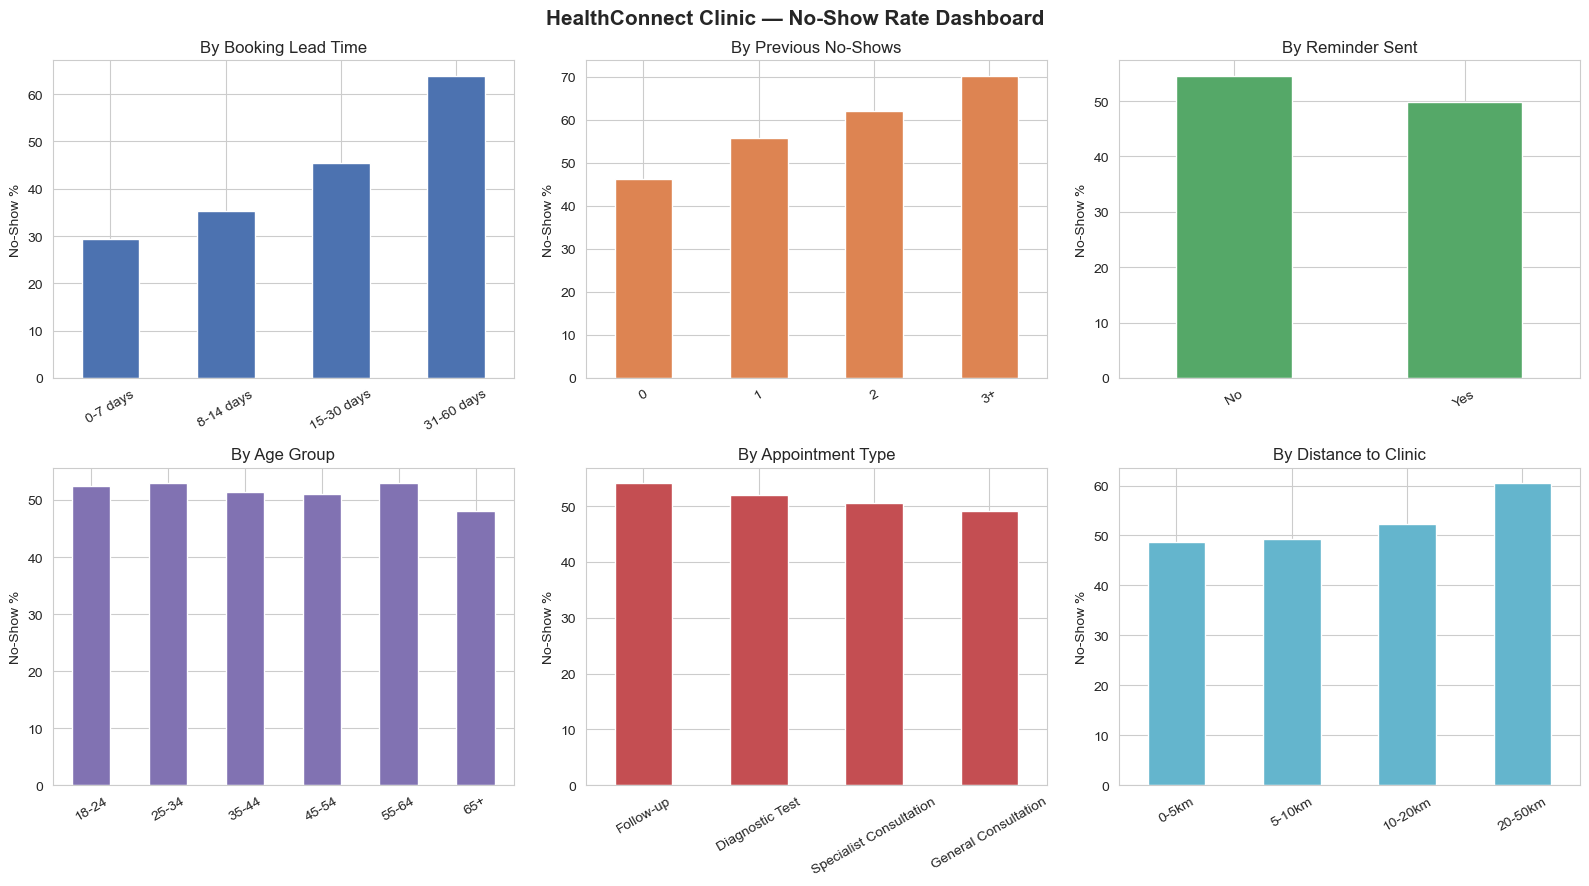

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))

lead_rate.plot(kind='bar', ax=axes[0,0], color='#4C72B0'); axes[0,0].set_title('By Booking Lead Time'); axes[0,0].set_ylabel('No-Show %')
prevns_rate.plot(kind='bar', ax=axes[0,1], color='#DD8452'); axes[0,1].set_title('By Previous No-Shows'); axes[0,1].set_ylabel('No-Show %')
reminder_rate.plot(kind='bar', ax=axes[0,2], color='#55A868'); axes[0,2].set_title('By Reminder Sent'); axes[0,2].set_ylabel('No-Show %')
age_rate.plot(kind='bar', ax=axes[1,0], color='#8172B2'); axes[1,0].set_title('By Age Group'); axes[1,0].set_ylabel('No-Show %')
type_rate.plot(kind='bar', ax=axes[1,1], color='#C44E52'); axes[1,1].set_title('By Appointment Type'); axes[1,1].set_ylabel('No-Show %')
dist_rate.plot(kind='bar', ax=axes[1,2], color='#64B5CD'); axes[1,2].set_title('By Distance to Clinic'); axes[1,2].set_ylabel('No-Show %')

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('')

fig.suptitle('HealthConnect Clinic — No-Show Rate Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 5: Business Insights

1. **Booking lead time is the single strongest predictor of no-shows.** Appointments booked more than a month in advance are more than twice as likely to be missed as those booked within a week (63.9% vs 29.5%). HealthConnect could introduce an extra confirmation step for appointments booked far ahead.

2. **Prior no-show history reliably signals future risk.** No-show likelihood climbs steadily from 46.3% to 70.3% as a patient's prior no-show count rises from 0 to 3+. This supports building a simple patient-level risk flag directly from existing data.

3. **Lead time and prior no-shows compound.** Patients who both book far ahead and have a history of no-shows reach an 81% no-show rate nearly 3.5x the rate of low-risk patients. This combined signal is more useful for prioritisation than either factor alone.

4. **Reminders work best when targeted, not blanket-sent.** The overall reminder effect is a modest 4.7 points, but it more than doubles (to ~12 points) for patients with 2+ prior no-shows. Redirecting reminder effort toward higher-risk patients could improve attendance without increasing total reminder volume.

5. **Distance matters mainly at the extremes.** Most patients live close to the clinic and show little variation in attendance, but patients 20-50km away have a noticeably higher no-show rate (60.5%) than those nearby (48.7%). This may point to transport as a barrier worth investigating for a specific subgroup of patients.

6. **Demographic factors (age, gender) are weak predictors.** Neither shows a meaningful relationship with attendance, suggesting HealthConnect's efforts are better spent on behavioural and logistical factors (lead time, history, reminders, distance) than on demographic targeting.

## Cross-Track Collaboration

**Track interacted with:** Data Science.

**Information/output exchanged:** The KPI results and the compounding effect between booking lead time and previous no-show history (Section 2.7) were identified as a candidate feature-engineering input combining these two variables into a single risk indicator rather than treating them separately.

**Why it was relevant:** The Data Science track's Week 5 focus includes feature engineering for a predictive no-show model. The interaction pattern found here gives a concrete, data-backed feature to test (e.g. a combined "lead time x prior no-shows" risk score) rather than the Data Science track needing to discover it independently.

**What changed or improved as a result:** This analysis output can shortcut part of the Data Science track's exploratory work and gives a business-justified rationale (not just a statistical one) for including that interaction as a model feature.

## Part 3 (Assignment): Assumptions, Limitations, Risks & Dependencies - Update

| Item | Week 4 Status | Week 5 Update |
|---|---|---|
| Missing values are structural, not errors | Assumed | Confirmed  `reminder_channel` missingness exactly matches `reminder_sent = No` |
| Dataset is clean (no duplicates/inconsistent labels) | Assumed | Confirmed on re-check |
| Distance to clinic has negligible effect | Initial finding | **Revised**  negligible for most patients, but a real effect emerges at 20-50km |
| Reminder effect is modest and uniform | Initial finding | **Revised**  effect is uniform, but its *size* varies significantly by patient risk group |
| Age and gender have little effect | Initial finding | Confirmed, no change |

**New issue discovered:** No timestamp exists for *when* a reminder was sent relative to the appointment date, only whether one was sent. This limits how precisely reminder timing could be optimised in a future stage.

**Potential impact:** The revised distance and reminder findings could change how Week 6 prioritises recommendations a targeted approach (by risk group, by distance) may be more impactful than an outcome measured only in aggregate.

**How addressed:** These refinements are carried forward into the Week 5 insights and will inform the Week 6 recommendation focus.

## Limitations

- The dataset is fictional and anonymised, so findings reflect patterns in simulated data rather than a real clinic population.
- No-show rates are calculated excluding cancellations; treating cancellations differently (e.g. as a partial negative outcome) could shift some KPI values slightly.
- Distance and reminder timing are only available at a coarse level (distance as a single value, reminder as sent/not sent), limiting how far these factors can be optimised without richer data.
- This analysis is descriptive, not predictive — it identifies associations, not causal relationships or a working prediction model.

## Recommendations for Week 6

1. Explore combining booking lead time and previous no-show count into a single composite risk indicator, since this analysis and the Data Science track can both use it.
2. Consider a targeted reminder strategy prioritising higher-risk patients rather than uniform reminders as a low-cost intervention with demonstrated impact.
3. Investigate the distance/no-show relationship further for the 20-50km segment specifically, to determine whether transport-related interventions are worth exploring.
4. Build the dashboard visuals developed here into a more polished, interactive report or BI tool (e.g. Power BI) for stakeholder use in later weeks.